# Фінальний проєкт. Частина 3: моделі на ембеддингах

Вхід: вектори фото і описів з ноутбука 02. Схема: лінійні моделі на ембеддингах як базова лінія, далі ознаки з
міток сусідів, кілька моделей першого рівня і бустинг другого рівня поверх усього.
Цільова змінна порядкова (1 швидко, 4 повільно), тому моделі дають число, а класи отримую порогами, підібраними
під quadratic weighted kappa.

In [1]:
import importlib.util
import subprocess
import sys

for pkg in ["catboost", "optuna", "lightgbm", "shap"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

In [2]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightgbm as lgb
import optuna
import shap
from catboost import CatBoostClassifier, CatBoostRegressor
from PIL import Image
from scipy.optimize import minimize
from scipy.stats import rankdata, spearmanr
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, Ridge, RidgeCV
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from transformers import AutoModel, AutoTokenizer, logging as hf_logging

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(device)

EMB_DIR = Path("Results/embeddings")
RES_DIR = Path("Results")
FIG_DIR = RES_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
assert (EMB_DIR / "pet_siglip2_mean.npy").exists(), "спочатку треба виконати 02_Embeddings_Parshyn.ipynb"

pets = pd.read_csv(EMB_DIR / "pets.csv", dtype={"PetID": str})
photos = pd.read_csv(EMB_DIR / "photos.csv", dtype={"PetID": str})
pets["Description"] = pets.Description.fillna("")

if not Path(photos.path.iloc[0]).exists():
    # кеш ембеддингів перенесли з іншої машини: шляхи до фото перебудовую так само, як у ноутбуці 02
    DATA_DIR = Path("Data")
    if not (DATA_DIR / "train.csv").exists():
        import kagglehub
        DATA_DIR = Path(kagglehub.competition_download("deep-learning-for-computer-vision-and-nlp-2026-10"))
    IMG_DIRS = {s: next(p for p in DATA_DIR.rglob(s) if p.is_dir() and any(p.glob("*.jpg"))) for s in ("train", "test")}
    photos["path"] = [str(IMG_DIRS[s] / Path(p).name) for s, p in zip(photos.split, photos.path)]
is_train = (pets.split == "train").values
tr_idx, te_idx = np.flatnonzero(is_train), np.flatnonzero(~is_train)
y = pets.AdoptionSpeed.values[tr_idx].astype(int)


def load_emb(name):
    e = np.load(EMB_DIR / f"{name}.npy").astype(np.float32)
    return e / np.clip(np.linalg.norm(e, axis=1, keepdims=True), 1e-6, None)


emb = {k: load_emb(k) for k in ["pet_clip_mean", "pet_clip_first", "pet_siglip2_mean", "text_clip", "text_bge"]}
for k, v in emb.items():
    print(f"{k:18s} {v.shape}")
print("train:", len(tr_idx), " test:", len(te_idx), " класи:", np.bincount(y)[1:])

mps
pet_clip_mean      (8322, 768)
pet_clip_first     (8322, 768)
pet_siglip2_mean   (8322, 1152)
text_clip          (8322, 768)
text_bge           (8322, 768)
train: 6431  test: 1891  класи: [1197 1773 1328 2133]


## Метрика і пороги

QWK карає квадратом відстані між класами: сплутати 1 і 4 у дев'ять разів гірше, ніж 1 і 2. Тому зручно
передбачати число, а класи різати порогами. Пороги підбираю методом Nelder-Mead прямо під QWK, стартуючи з
квантилів, які відтворюють частоти класів train. Щоб оцінка в крос-валідації не була завищеною, пороги для
кожного фолду беру з OOF-прогнозів решти фолдів.

In [3]:
def qwk(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights="quadratic")


def apply_thresholds(pred, thr):
    return 1 + np.searchsorted(np.sort(thr), pred)


def fit_thresholds(pred, y_true):
    cum = np.cumsum(np.bincount(y_true, minlength=5)[1:4]) / len(y_true)
    init = np.quantile(pred, cum)
    loss = lambda thr: -qwk(y_true, apply_thresholds(pred, thr))
    return np.sort(minimize(loss, init, method="Nelder-Mead", options={"xatol": 1e-4, "maxiter": 400}).x)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(skf.split(tr_idx, y))      # позиції в межах train, одні й ті самі для всіх моделей


def cv_qwk(oof, y_true=y):
    pred = np.zeros(len(y_true), int)
    for tr, va in folds:
        pred[va] = apply_thresholds(oof[va], fit_thresholds(oof[tr], y_true[tr]))
    return qwk(y_true, pred), pred


results = {}


def report(name, oof):
    score, pred = cv_qwk(oof)
    fold_std = np.std([qwk(y[va], pred[va]) for _, va in folds])    # розкид між фолдами, щоб бачити, що є шумом
    results[name] = (score, fold_std)
    print(f"{name:48s} QWK = {score:.4f}  (std по фолдах {fold_std:.3f})")


def cv_predict(make_model, X, proba=False):
    # OOF-прогноз для train і прогноз для test моделлю, навченою на всьому train
    X_tr, X_te = X[tr_idx], X[te_idx]
    oof = np.zeros((len(tr_idx), 4) if proba else len(tr_idx))
    for tr, va in folds:
        model = make_model().fit(X_tr[tr], y[tr])
        oof[va] = model.predict_proba(X_tr[va]) if proba else model.predict(X_tr[va])
    model = make_model().fit(X_tr, y)
    test = model.predict_proba(X_te) if proba else model.predict(X_te)
    return oof, test

## Базові моделі

Ridge на кожному наборі ознак окремо. Це відповідь на питання, де сигнал: у метаданих, тексті чи фото, у першому
фото чи в усіх, у CLIP чи в SigLIP2. RidgeCV сам обирає силу регуляризації, лише для розрідженої матриці TF-IDF
на 35 тисяч стовпців alpha фіксую. Константний прогноз дає QWK = 0 за означенням, тому перша реальна лінія -
кількість фото і довжина опису.

In [4]:
n_words = pets.Description.str.split().str.len().values
meta_X = np.c_[pets.n_img.values, np.log1p(pets.n_img.values), n_words, np.log1p(n_words)].astype(np.float32)

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=50_000, sublinear_tf=True)
X_tfidf = tfidf.fit_transform(pets.Description)
print("TF-IDF:", X_tfidf.shape)

ridge_cv = lambda: RidgeCV(alphas=np.logspace(-1, 4, 11))
feature_sets = {
    "meta": ("мета: кількість фото, довжина опису", meta_X),
    "tfidf": ("текст: TF-IDF", X_tfidf),
    "text_clip": ("текст: CLIP text", emb["text_clip"]),
    "text_bge": ("текст: bge", emb["text_bge"]),
    "clip_first": ("фото: CLIP, тільки перше фото", emb["pet_clip_first"]),
    "clip": ("фото: CLIP, середнє по всіх фото", emb["pet_clip_mean"]),
    "siglip2": ("фото: SigLIP2, середнє по всіх фото", emb["pet_siglip2_mean"]),
    "img": ("фото: CLIP + SigLIP2", np.hstack([emb["pet_clip_mean"], emb["pet_siglip2_mean"]])),
    "all": ("фото + текст: усі ембеддинги", np.hstack([emb["pet_clip_mean"], emb["pet_siglip2_mean"], emb["text_clip"], emb["text_bge"]])),
}
ridge_preds = {}      # OOF і test прогнози кожної базової лінії, далі вони стануть ознаками другого рівня
for key, (label, X) in feature_sets.items():
    make = (lambda: Ridge(alpha=3.0)) if key == "tfidf" else ridge_cv    # RidgeCV на розрідженій матриці повільний
    ridge_preds[key] = cv_predict(make, X)
    report(f"Ridge, {label}", ridge_preds[key][0])

TF-IDF: (8322, 34662)


Ridge, мета: кількість фото, довжина опису       QWK = 0.0915  (std по фолдах 0.030)


Ridge, текст: TF-IDF                             QWK = 0.3437  (std по фолдах 0.007)


Ridge, текст: CLIP text                          QWK = 0.3410  (std по фолдах 0.027)


Ridge, текст: bge                                QWK = 0.2965  (std по фолдах 0.019)


Ridge, фото: CLIP, тільки перше фото             QWK = 0.5623  (std по фолдах 0.019)


Ridge, фото: CLIP, середнє по всіх фото          QWK = 0.5869  (std по фолдах 0.016)


Ridge, фото: SigLIP2, середнє по всіх фото       QWK = 0.5921  (std по фолдах 0.013)


Ridge, фото: CLIP + SigLIP2                      QWK = 0.5910  (std по фолдах 0.012)


Ridge, фото + текст: усі ембеддинги              QWK = 0.5964  (std по фолдах 0.018)


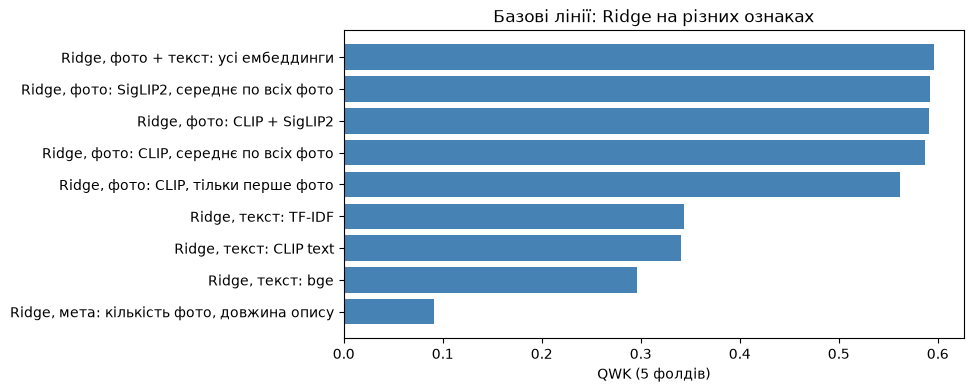

In [5]:
base = pd.Series({k: v[0] for k, v in results.items()}).sort_values()
plt.figure(figsize=(8, 4))
plt.barh(base.index, base.values, color="steelblue")
plt.xlabel("QWK (5 фолдів)")
plt.title("Базові лінії: Ridge на різних ознаках")
plt.savefig(FIG_DIR / "models_baselines.png", dpi=120, bbox_inches="tight")
plt.show()

## Ознаки з міток сусідів

Однакові або схожі оголошення (один притулок, та сама серія фото) часто мають однакову швидкість адопції.
Для кожної тварини шукаю 20 найближчих за косинусом тварин з train і беру статистики їхніх міток: середню по
топ-5 і топ-20, зважену softmax-вагами, мітку і схожість найближчого, частки класів серед сусідів.
Щоб не підглядати у власну мітку, для рядків train сусідів шукаю серед решти train (leave-one-out), а всередині
крос-валідації тільки серед навчальної частини фолду. Окремо рахую дублікати опису слово в слово.

In [6]:
K = 20


def unit(a):
    return a / np.clip(np.linalg.norm(a, axis=1, keepdims=True), 1e-6, None)


spaces = {
    "img": unit(np.hstack([emb["pet_clip_mean"], emb["pet_siglip2_mean"]])),
    "txt": emb["text_bge"],
    "all": unit(np.hstack([emb["pet_clip_mean"], emb["pet_siglip2_mean"], emb["text_clip"], emb["text_bge"]])),
}
spaces = {k: torch.tensor(v, device=device) for k, v in spaces.items()}
labels_all = torch.tensor(np.nan_to_num(pets.AdoptionSpeed.values), device=device, dtype=torch.float32)
desc_key = pets.Description.str.lower().str.replace(r"\s+", " ", regex=True).str.strip().values


def knn_block(E, q_idx, ref_idx, exclude_self):
    S = E[q_idx] @ E[ref_idx].T
    if exclude_self:
        S.fill_diagonal_(-2.0)                       # q_idx == ref_idx, себе не рахую
    sim, pos = S.topk(K, dim=1)
    lab = labels_all[torch.as_tensor(ref_idx, device=device)[pos]]
    w = torch.softmax(sim / 0.05, dim=1)
    feats = [lab[:, :5].mean(1), lab.mean(1), (w * lab).sum(1), lab[:, 0], sim[:, 0], sim[:, :5].mean(1)]
    feats += [(lab == c).float().mean(1) for c in range(1, 5)]
    return torch.stack(feats, 1).cpu().numpy()


def dup_block(q_idx, ref_idx, exclude_self):
    ref = pd.DataFrame({"key": desc_key[ref_idx], "y": pets.AdoptionSpeed.values[ref_idx]})
    g = ref[ref.key != ""].groupby("key").y.agg(["sum", "count"])
    s = np.nan_to_num(g["sum"].reindex(desc_key[q_idx]).values)
    c = np.nan_to_num(g["count"].reindex(desc_key[q_idx]).values)
    if exclude_self:
        own = desc_key[q_idx] != ""
        s, c = s - own * pets.AdoptionSpeed.values[q_idx], c - own
    mean = np.where(c > 0, s / np.maximum(c, 1), np.nan)
    return np.c_[c, mean]


def knn_features(q_idx, ref_idx, exclude_self=False):
    if exclude_self:
        assert np.array_equal(q_idx, ref_idx)
    blocks = [knn_block(E, q_idx, ref_idx, exclude_self) for E in spaces.values()]
    return np.hstack(blocks + [dup_block(q_idx, ref_idx, exclude_self)])


stat_names = ["mean5", "mean20", "wmean", "nn_label", "nn_sim", "sim5", "p1", "p2", "p3", "p4"]
knn_names = [f"knn_{s}_{f}" for s in spaces for f in stat_names] + ["dup_count", "dup_mean"]

knn_loo = pd.DataFrame(knn_features(tr_idx, tr_idx, exclude_self=True), columns=knn_names)
corr = knn_loo.apply(lambda col: spearmanr(col, y, nan_policy="omit").correlation)
print("кореляція Спірмена з AdoptionSpeed:")
print(corr.sort_values(key=np.abs, ascending=False).round(3).head(12).to_string())
print(f"\nрядків з дублікатом опису в train: {(knn_loo.dup_count > 0).sum()}")
report("kNN: зважена середня мітка сусідів (фото + текст)", knn_loo.knn_all_wmean.values)
report("kNN: зважена середня мітка сусідів (тільки фото)", knn_loo.knn_img_wmean.values)

кореляція Спірмена з AdoptionSpeed:
dup_mean            0.706
knn_img_wmean       0.567
knn_img_mean20      0.555
knn_all_wmean       0.545
knn_img_p4          0.528
knn_img_mean5       0.526
knn_all_mean20      0.515
knn_all_mean5       0.475
knn_all_p4          0.466
knn_img_p1         -0.453
knn_all_p1         -0.392
knn_img_nn_label    0.390

рядків з дублікатом опису в train: 427


kNN: зважена середня мітка сусідів (фото + текст) QWK = 0.5174  (std по фолдах 0.012)


kNN: зважена середня мітка сусідів (тільки фото) QWK = 0.5435  (std по фолдах 0.016)


## Моделі першого рівня

Ridge з базових ліній уже дав по одному прогнозу на кожен набір ознак, усі вони підуть на другий рівень: так
бустинг сам зважить, скільки вірити фото, а скільки тексту. Сюди додаю моделі на повному стандартизованому
векторі ембеддингів (CLIP + SigLIP2 + два текстові): SVR дає число, логістична регресія і MLP дають імовірності
класів. OOF-прогнози стають ознаками другого рівня, прогнози для test роблять моделі, перенавчені на всьому train.

MLP пишу сам: два шари, dropout, L2-штраф на ваги, доданий прямо у функцію втрат, і label smoothing. Кількість
епох фіксована, без ранньої зупинки на валідаційному фолді, інакше OOF-прогноз був би оптимістичним.

In [7]:
X_all = np.hstack([emb["pet_clip_mean"], emb["pet_siglip2_mean"], emb["text_clip"], emb["text_bge"]])
X_std = StandardScaler().fit_transform(X_all).astype(np.float32)
print(X_std.shape)

level1 = {}
for name, make, proba in [
    ("svr", lambda: SVR(C=1.0, epsilon=0.2), False),
    ("logreg", lambda: LogisticRegression(C=0.005, max_iter=1000), True),
]:
    t0 = time.time()
    level1[name] = cv_predict(make, X_std, proba=proba)
    oof = level1[name][0] @ np.arange(1, 5) if proba else level1[name][0]
    report(f"L1 {name}", oof)
    print(f"{'':48s} {time.time() - t0:.0f} с")

(8322, 3456)


L1 svr                                           QWK = 0.6093  (std по фолдах 0.016)
                                                 110 с


L1 logreg                                        QWK = 0.5571  (std по фолдах 0.015)
                                                 4 с


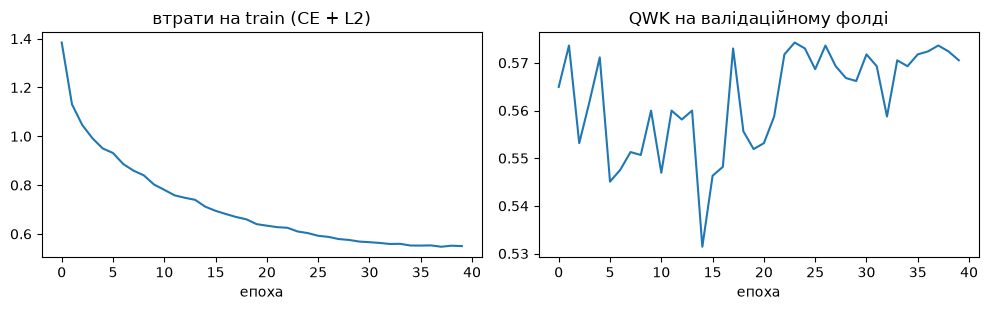

In [8]:
class MLP(nn.Module):
    def __init__(self, d_in, d_hidden=512, n_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(0.2), nn.Linear(d_in, d_hidden), nn.GELU(),
            nn.Dropout(0.5), nn.Linear(d_hidden, n_classes),
        )

    def forward(self, x):
        return self.net(x)


def mlp_loss(model, logits, target, l2=3e-4):
    penalty = sum(p.pow(2).sum() for p in model.parameters() if p.ndim == 2)
    return F.cross_entropy(logits, target, label_smoothing=0.1) + l2 * penalty


def fit_mlp(X_tr, y_tr, X_ev, epochs=25, lr=1e-3, batch_size=128, eval_each_epoch=None):
    torch.manual_seed(SEED)
    model = MLP(X_tr.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    Xt, yt = torch.tensor(X_tr, device=device), torch.tensor(y_tr - 1, device=device)
    Xe = torch.tensor(X_ev, device=device)
    cum_train = np.cumsum(np.bincount(y_tr, minlength=5)[1:4]) / len(y_tr)   # для кривої пороги за частотами train, без міток валідації
    history = []
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(Xt), device=device)
        total = 0.0
        for i in range(0, len(Xt), batch_size):
            b = perm[i:i + batch_size]
            loss = mlp_loss(model, model(Xt[b]), yt[b])
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item() * len(b)
        sched.step()
        if eval_each_epoch is not None:
            model.eval()
            with torch.no_grad():
                ev = torch.softmax(model(Xe), 1).cpu().numpy() @ np.arange(1, 5)
            history.append((total / len(Xt), qwk(eval_each_epoch, apply_thresholds(ev, np.quantile(ev, cum_train)))))
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(Xe), 1).cpu().numpy()
    return probs, history


# крива навчання на фолді 0, за нею обрано epochs=25 для всіх фолдів
tr, va = folds[0]
_, hist = fit_mlp(X_std[tr_idx][tr], y[tr], X_std[tr_idx][va], epochs=40, eval_each_epoch=y[va])
hist = np.array(hist)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(hist[:, 0]); ax[0].set_title("втрати на train (CE + L2)"); ax[0].set_xlabel("епоха")
ax[1].plot(hist[:, 1]); ax[1].set_title("QWK на валідаційному фолді"); ax[1].set_xlabel("епоха")
plt.tight_layout()
plt.savefig(FIG_DIR / "models_mlp_curve.png", dpi=120, bbox_inches="tight")
plt.show()

In [9]:
t0 = time.time()
oof = np.zeros((len(tr_idx), 4))
for tr, va in folds:
    oof[va] = fit_mlp(X_std[tr_idx][tr], y[tr], X_std[tr_idx][va])[0]
test = fit_mlp(X_std[tr_idx], y, X_std[te_idx])[0]
level1["mlp"] = (oof, test)
report("L1 MLP (CE + L2 + label smoothing)", oof @ np.arange(1, 5))
print(f"{'':48s} {time.time() - t0:.0f} с")

L1 MLP (CE + L2 + label smoothing)               QWK = 0.5757  (std по фолдах 0.014)
                                                 11 с


## Другий рівень

Ознаки другого рівня: статистики міток сусідів, OOF-прогнози першого рівня, кількість фото і довжина опису,
і стиснуті PCA ембеддинги (по 32 компоненти на енкодер), щоб бустинг бачив і сирий сигнал. Усередині
крос-валідації ознаки сусідів для навчальної частини рахую leave-one-out у межах цієї частини, для
валідаційної проти навчальної. Так само буде на test.

Моделі: LightGBM регресія, LightGBM multiclass (очікуване значення за ймовірностями), порядкова схема
Франка-Холла з трьох бінарних LightGBM (P(y>1) + P(y>2) + P(y>3) + 1 дає очікуваний клас), CatBoost multiclass
і CatBoost регресія. Усі дають число, далі пороги. Фінальний прогноз - середнє рангів моделей.

In [10]:
pca_parts = {k: PCA(32, random_state=SEED).fit_transform(emb[k]) for k in ["pet_clip_mean", "pet_siglip2_mean", "text_bge"]}
pca_X = np.hstack(list(pca_parts.values())).astype(np.float32)
pca_names = [f"pca_{k.replace('pet_', '').replace('_mean', '')}_{i}" for k in pca_parts for i in range(32)]
meta_names = ["n_img", "log_n_img", "n_words", "log_n_words"]
l1_names = [f"l1_ridge_{k}" for k in feature_sets] + ["l1_svr"] + [f"l1_logreg_p{c}" for c in range(1, 5)] + [f"l1_mlp_p{c}" for c in range(1, 5)]
feature_names = knn_names + l1_names + meta_names + pca_names


def level1_matrix(part):
    ridge_cols = np.column_stack([ridge_preds[k][part] for k in feature_sets])
    return np.hstack([ridge_cols, level1["svr"][part][:, None], level1["logreg"][part], level1["mlp"][part]])


L1_train, L1_test = level1_matrix(0), level1_matrix(1)


def build_features(q_idx, ref_idx, l1_rows, exclude_self):
    return np.hstack([knn_features(q_idx, ref_idx, exclude_self), l1_rows, meta_X[q_idx], pca_X[q_idx]])


fold_data = []
for tr, va in folds:
    F_tr = build_features(tr_idx[tr], tr_idx[tr], L1_train[tr], exclude_self=True)
    F_va = build_features(tr_idx[va], tr_idx[tr], L1_train[va], exclude_self=False)
    fold_data.append((F_tr, y[tr], F_va))
print("ознак другого рівня:", F_tr.shape[1], " сімейства:", len(knn_names), len(l1_names), len(meta_names), len(pca_names))


def cv_level2(fit_predict):
    oof = np.zeros(len(tr_idx))
    for (F_tr, y_tr, F_va), (tr, va) in zip(fold_data, folds):
        oof[va] = fit_predict(F_tr, y_tr, F_va)
    return oof

ознак другого рівня: 150  сімейства: 32 18 4 96


In [11]:
LGB_PARAMS = dict(n_estimators=800, learning_rate=0.02, num_leaves=7, min_child_samples=40, subsample=0.8,
                  subsample_freq=1, colsample_bytree=0.3, reg_lambda=1.0, random_state=SEED, verbose=-1)
CLASSES = np.arange(1, 5)


def lgb_reg(F_tr, y_tr, F_va, params=LGB_PARAMS):
    return lgb.LGBMRegressor(**params).fit(F_tr, y_tr).predict(F_va)


def lgb_multi(F_tr, y_tr, F_va, params=LGB_PARAMS):
    return lgb.LGBMClassifier(**params).fit(F_tr, y_tr).predict_proba(F_va) @ CLASSES


def lgb_ordinal(F_tr, y_tr, F_va, params=LGB_PARAMS):
    # Frank & Hall: три бінарні задачі "y > k", сума ймовірностей дає очікуваний клас
    return 1 + sum(lgb.LGBMClassifier(**params).fit(F_tr, (y_tr > k).astype(int)).predict_proba(F_va)[:, 1] for k in (1, 2, 3))


CAT_PARAMS = dict(iterations=800, learning_rate=0.05, depth=6, random_seed=SEED, verbose=0, allow_writing_files=False, thread_count=-1)


def cat_multi(F_tr, y_tr, F_va):
    return CatBoostClassifier(**CAT_PARAMS).fit(F_tr, y_tr).predict_proba(F_va) @ CLASSES


def cat_reg(F_tr, y_tr, F_va):
    return CatBoostRegressor(**CAT_PARAMS).fit(F_tr, y_tr).predict(F_va)


level2_fns = {"LGBM регресія": lgb_reg, "LGBM multiclass": lgb_multi, "LGBM порядкова": lgb_ordinal,
              "CatBoost multiclass": cat_multi, "CatBoost регресія": cat_reg}
level2 = {}
for name, fn in level2_fns.items():
    t0 = time.time()
    level2[name] = cv_level2(fn)
    report(f"L2 {name}", level2[name])
    print(f"{'':48s} {time.time() - t0:.0f} с")


def rank_blend(preds):
    return np.mean([rankdata(p) / len(p) for p in preds], axis=0)


blend_oof = rank_blend(list(level2.values()))
report("L2 бленд: середнє рангів 5 моделей", blend_oof)

L2 LGBM регресія                                 QWK = 0.6048  (std по фолдах 0.016)
                                                 7 с


L2 LGBM multiclass                               QWK = 0.6126  (std по фолдах 0.017)
                                                 25 с


L2 LGBM порядкова                                QWK = 0.6092  (std по фолдах 0.017)
                                                 20 с


L2 CatBoost multiclass                           QWK = 0.6123  (std по фолдах 0.013)
                                                 31 с


L2 CatBoost регресія                             QWK = 0.5979  (std по фолдах 0.011)
                                                 11 с


L2 бленд: середнє рангів 5 моделей               QWK = 0.6096  (std по фолдах 0.017)


## Дисбаланс класів

Класи 1 і 3 менші за 2 і 4. Два прості ходи: ваги класів у LightGBM multiclass і пороги, які вже підлаштовують
розподіл прогнозів під QWK. Порівнюю з наївним округленням регресії: воно майже не передбачає малі класи,
пороги повертають їм recall. Ваги класів поверх порогів уже нічого не додають, тому у фінал ідуть тільки пороги.

In [12]:
lgb_multi_balanced = lambda F_tr, y_tr, F_va: lgb_multi(F_tr, y_tr, F_va, dict(LGB_PARAMS, class_weight="balanced"))
oof_bal = cv_level2(lgb_multi_balanced)
report("L2 LGBM multiclass, class_weight=balanced", oof_bal)

reg_oof = level2["LGBM регресія"]
rounded = np.clip(np.rint(reg_oof), 1, 4).astype(int)
_, thresholded = cv_qwk(reg_oof)
print(f"\nLGBM регресія, округлення без порогів: QWK = {qwk(y, rounded):.4f}")
print(f"LGBM регресія, пороги під QWK:         QWK = {results['L2 LGBM регресія'][0]:.4f}")


def recall_table(pred):
    cm = confusion_matrix(y, pred, labels=CLASSES)
    return pd.DataFrame({"справжні": np.bincount(y)[1:], "передбачені": np.bincount(pred)[1:],
                         "recall": np.diag(cm) / cm.sum(1)}, index=CLASSES).round(3)


print("\nокруглення:\n", recall_table(rounded).to_string())
print("\nпороги:\n", recall_table(thresholded).to_string())

L2 LGBM multiclass, class_weight=balanced        QWK = 0.6068  (std по фолдах 0.015)



LGBM регресія, округлення без порогів: QWK = 0.5581
LGBM регресія, пороги під QWK:         QWK = 0.6048

округлення:
    справжні  передбачені  recall
1      1197          261   0.140
2      1773         2514   0.593
3      1328         2508   0.530
4      2133         1148   0.436

пороги:
    справжні  передбачені  recall
1      1197         1056   0.443
2      1773         1840   0.444
3      1328         1585   0.363
4      2133         1950   0.653


## Optuna для LightGBM

Підбираю гіперпараметри регресійного LightGBM на тих самих фолдах, ціль та сама: QWK з порогами. Першою спробою
ставлю поточні LGB_PARAMS, щоб було з чим порівнювати. Оцінка найкращої спроби за побудовою трохи завищена,
бо вона обрана на цих самих фолдах, тому приріст порівнюю з розкидом по фолдах, а не беру на віру.
Знайдені параметри потім ставлю і в multiclass, і в порядкову схему. Фінальний бленд збираю з трьох
класифікаційних моделей: multiclass і порядковий LightGBM з параметрами Optuna та CatBoost multiclass.
Регресійні варіанти стабільно слабші, їх лишаю тільки в таблиці.

In [13]:
SEARCH_KEYS = ["num_leaves", "learning_rate", "min_child_samples", "colsample_bytree", "subsample", "reg_lambda", "n_estimators"]


def objective(trial):
    params = dict(LGB_PARAMS,
                  num_leaves=trial.suggest_int("num_leaves", 3, 48),
                  learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                  min_child_samples=trial.suggest_int("min_child_samples", 5, 80),
                  colsample_bytree=trial.suggest_float("colsample_bytree", 0.2, 0.9),
                  subsample=trial.suggest_float("subsample", 0.5, 1.0),
                  reg_lambda=trial.suggest_float("reg_lambda", 1e-2, 30.0, log=True),
                  n_estimators=trial.suggest_int("n_estimators", 200, 1500))
    return cv_qwk(cv_level2(lambda a, b, c: lgb_reg(a, b, c, params)))[0]


t0 = time.time()
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.enqueue_trial({k: LGB_PARAMS[k] for k in SEARCH_KEYS})
study.optimize(objective, n_trials=30, timeout=1800)      # на 2 ядрах Colab може встигнути менше спроб
print(f"спроб: {len(study.trials)}, {time.time() - t0:.0f} с")
print(f"базові параметри: QWK = {study.trials[0].value:.4f}, найкращі: QWK = {study.best_value:.4f}")
print(study.best_params)
print("важливість гіперпараметрів:", {k: round(v, 2) for k, v in optuna.importance.get_param_importances(study).items()})

LGB_TUNED = dict(LGB_PARAMS, **study.best_params)
tuned_fns = {
    "LGBM регресія (Optuna)": lambda F_tr, y_tr, F_va: lgb_reg(F_tr, y_tr, F_va, LGB_TUNED),
    "LGBM multiclass (Optuna)": lambda F_tr, y_tr, F_va: lgb_multi(F_tr, y_tr, F_va, LGB_TUNED),
    "LGBM порядкова (Optuna)": lambda F_tr, y_tr, F_va: lgb_ordinal(F_tr, y_tr, F_va, LGB_TUNED),
}
for name, fn in tuned_fns.items():
    level2[name] = cv_level2(fn)
    report(f"L2 {name}", level2[name])

# регресійні варіанти стабільно слабші за класифікаційні, тому у фінальний бленд ідуть три моделі:
# multiclass і порядковий LightGBM з параметрами Optuna та CatBoost multiclass
final_fns = {"LGBM multiclass (Optuna)": tuned_fns["LGBM multiclass (Optuna)"],
             "LGBM порядкова (Optuna)": tuned_fns["LGBM порядкова (Optuna)"],
             "CatBoost multiclass": cat_multi}
blend_oof = rank_blend([level2[name] for name in final_fns])
report("L2 фінальний бленд: середнє рангів 3 моделей", blend_oof)

спроб: 30, 424 с
базові параметри: QWK = 0.6048, найкращі: QWK = 0.6094
{'num_leaves': 3, 'learning_rate': 0.010878598823335986, 'min_child_samples': 5, 'colsample_bytree': 0.2362360268477754, 'subsample': 0.6560967642317885, 'reg_lambda': 0.13201772426751918, 'n_estimators': 1304}
важливість гіперпараметрів: {'learning_rate': 0.33, 'min_child_samples': 0.29, 'colsample_bytree': 0.19, 'reg_lambda': 0.08, 'n_estimators': 0.05, 'subsample': 0.03, 'num_leaves': 0.03}


L2 LGBM регресія (Optuna)                        QWK = 0.6094  (std по фолдах 0.014)


L2 LGBM multiclass (Optuna)                      QWK = 0.6157  (std по фолдах 0.014)


L2 LGBM порядкова (Optuna)                       QWK = 0.6102  (std по фолдах 0.018)


L2 фінальний бленд: середнє рангів 3 моделей     QWK = 0.6127  (std по фолдах 0.015)


In [14]:
summary = pd.DataFrame(results, index=["QWK", "std_folds"]).T.sort_values("QWK", ascending=False)
summary.to_csv(RES_DIR / "cv_results.csv")
print(summary.round(4).to_string())

                                                      QWK  std_folds
L2 LGBM multiclass (Optuna)                        0.6157     0.0145
L2 фінальний бленд: середнє рангів 3 моделей       0.6127     0.0152
L2 LGBM multiclass                                 0.6126     0.0171
L2 CatBoost multiclass                             0.6123     0.0127
L2 LGBM порядкова (Optuna)                         0.6102     0.0176
L2 бленд: середнє рангів 5 моделей                 0.6096     0.0169
L2 LGBM регресія (Optuna)                          0.6094     0.0135
L1 svr                                             0.6093     0.0156
L2 LGBM порядкова                                  0.6092     0.0167
L2 LGBM multiclass, class_weight=balanced          0.6068     0.0153
L2 LGBM регресія                                   0.6048     0.0163
L2 CatBoost регресія                               0.5979     0.0105
Ridge, фото + текст: усі ембеддинги                0.5964     0.0185
Ridge, фото: SigLIP2, середнє по в

## Інтерпретація

Що рухає прогноз: SHAP для налаштованого LightGBM, зібраний по сімействах ознак, і таблиця окремих ознак.
Далі аблація на тих самих фолдах: прибираю по одному сімейству ознак другого рівня і дивлюся, скільки QWK
втрачає найкраща модель. Потім zero-shot зондування простору CLIP: наскільки схожість фото з текстовим
запитом корелює зі швидкістю адопції. І наостанок тварини, яким модель пророкує найшвидшу і найповільнішу адопцію.

частка |SHAP| за сімействами ознак:
моделі першого рівня        0.572
PCA фото                    0.169
сусіди за фото + текстом    0.098
PCA тексту                  0.057
сусіди за фото              0.055
сусіди за текстом           0.040
метадані                    0.006
дублікати опису             0.003

топ-12 ознак:
l1_svr                 0.159
l1_ridge_siglip2       0.071
l1_ridge_all           0.066
l1_ridge_img           0.063
l1_ridge_clip          0.060
l1_mlp_p4              0.046
knn_all_wmean          0.039
l1_ridge_clip_first    0.036
knn_all_nn_label       0.024
knn_all_mean5          0.021
l1_logreg_p4           0.016
knn_txt_nn_label       0.015


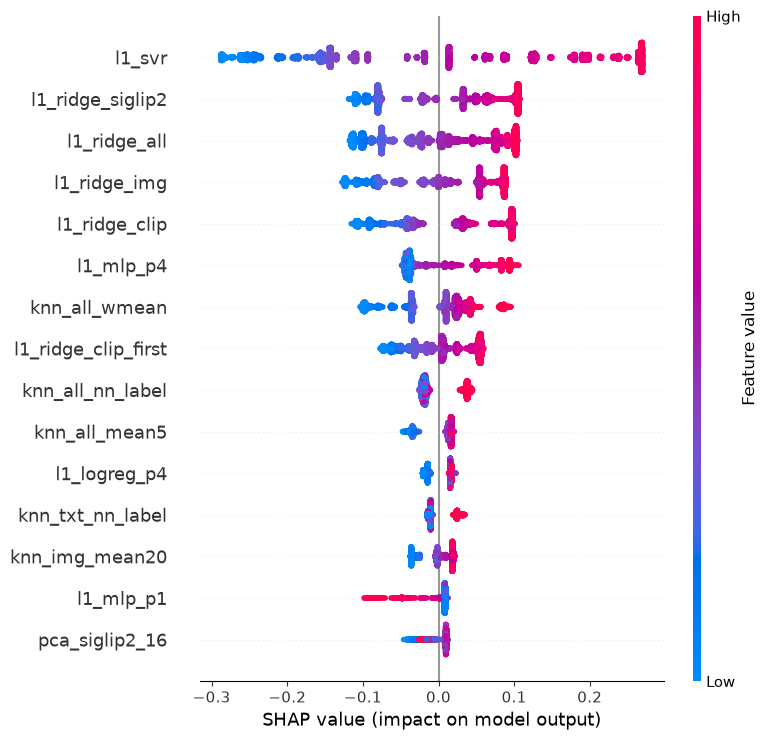

In [15]:
F_train = build_features(tr_idx, tr_idx, L1_train, exclude_self=True)
F_test = build_features(te_idx, tr_idx, L1_test, exclude_self=False)

model = lgb.LGBMRegressor(**LGB_TUNED).fit(F_train, y)
shap_values = shap.TreeExplainer(model).shap_values(F_train)
imp = pd.Series(np.abs(shap_values).mean(0), index=feature_names)


def family(name):
    if name.startswith("knn_img"):
        return "сусіди за фото"
    if name.startswith("knn_txt"):
        return "сусіди за текстом"
    if name.startswith("knn_all"):
        return "сусіди за фото + текстом"
    if name.startswith("dup"):
        return "дублікати опису"
    if name.startswith("l1"):
        return "моделі першого рівня"
    if name.startswith("pca_text"):
        return "PCA тексту"
    if name.startswith("pca"):
        return "PCA фото"
    return "метадані"


fam = (imp.groupby(imp.index.map(family)).sum() / imp.sum()).sort_values(ascending=False)
print("частка |SHAP| за сімействами ознак:")
print(fam.round(3).to_string())
print("\nтоп-12 ознак:")
print((imp / imp.sum()).sort_values(ascending=False).head(12).round(3).to_string())

shap.summary_plot(shap_values, F_train, feature_names=feature_names, max_display=15, show=False)
plt.savefig(FIG_DIR / "models_shap.png", dpi=120, bbox_inches="tight")
plt.show()

In [16]:
# аблація: та сама LGBM multiclass з параметрами Optuna, але без одного сімейства ознак
fam_of = np.array([family(n) for n in feature_names])
ablation = {}
for fam in ["сусіди за фото", "сусіди за текстом", "сусіди за фото + текстом", "моделі першого рівня", "PCA фото", "PCA тексту"]:
    keep = fam_of != fam
    oof = np.zeros(len(tr_idx))
    for (F_tr, y_tr, F_va), (tr, va) in zip(fold_data, folds):
        oof[va] = lgb_multi(F_tr[:, keep], y_tr, F_va[:, keep], LGB_TUNED)
    ablation[fam] = cv_qwk(oof)[0]
full = results["L2 LGBM multiclass (Optuna)"][0]
print(f"повний набір ознак: QWK = {full:.4f}")
print(pd.Series({f"без: {k}": v - full for k, v in ablation.items()}, name="зміна QWK").round(4).to_string())

повний набір ознак: QWK = 0.6157
без: сусіди за фото             -0.0045
без: сусіди за текстом          -0.0023
без: сусіди за фото + текстом   -0.0069
без: моделі першого рівня       -0.0220
без: PCA фото                   -0.0002
без: PCA тексту                 -0.0021


In [17]:
tokenizer = AutoTokenizer.from_pretrained("openai/clip-vit-large-patch14")
clip = AutoModel.from_pretrained("openai/clip-vit-large-patch14").eval()
prompts = {
    "кошеня або цуценя": "a photo of a kitten or a puppy",
    "доросла тварина": "a photo of an adult cat or dog",
    "стара тварина": "a photo of an old animal",
    "хвора або поранена тварина": "a photo of a sick or injured animal",
    "тварина в клітці": "a photo of an animal in a cage",
    "тварина на руках у людини": "a photo of a person holding a pet",
    "розмите фото поганої якості": "a blurry low quality photo",
    "породиста тварина": "a photo of a purebred pedigree animal",
    "кілька тварин разом": "a photo of several animals together",
}
with torch.no_grad():
    out = clip.get_text_features(**tokenizer(list(prompts.values()), padding=True, return_tensors="pt"))
P = out.pooler_output if hasattr(out, "pooler_output") else out      # transformers 5 повертає обгортку, 4.x тензор
P = F.normalize(P, dim=-1).numpy()
sims = emb["pet_clip_mean"][tr_idx] @ P.T
probe = pd.Series({k: spearmanr(sims[:, j], y).correlation for j, k in enumerate(prompts)}, name="кореляція з AdoptionSpeed")
print("плюс означає повільнішу адопцію")
print(probe.sort_values().round(3).to_string())
del clip

плюс означає повільнішу адопцію
кошеня або цуценя             -0.319
тварина на руках у людини     -0.159
породиста тварина             -0.050
стара тварина                 -0.042
розмите фото поганої якості   -0.041
тварина в клітці              -0.025
хвора або поранена тварина    -0.007
доросла тварина                0.009
кілька тварин разом            0.106


## Фінальне навчання і сабмішен

Ознаки test: сусіди серед усього train, прогнози першого рівня від моделей, перенавчених на всьому train.
Моделі другого рівня теж перенавчаю на всьому train, бленд рангів, пороги з OOF-бленду. Test не має міток, тому
"усі доступні дані" для навчання з учителем - це весь train, а ембеддинги test уже використані в PCA і як
кандидати в сусіди не використовуються, бо міток у них немає.

пороги на рангах: [0.167 0.421 0.719]


фінальний бленд, recall по класах (OOF):
    справжні  передбачені  recall
1      1197         1120   0.481
2      1773         1706   0.434
3      1328         1745   0.428
4      2133         1860   0.643
   train  submission
1  0.186       0.165
2  0.276       0.254
3  0.206       0.299
4  0.332       0.282
       PetID  AdoptionSpeed
0  6697a7f62              3
1  23b64fe21              2
2  41e824cbe              4
3  6c3d7237b              4
4  97b0b5d92              3
PetID з 8 символів у сабмішені: ['95314294', '35992662', '63521459', '81301773']


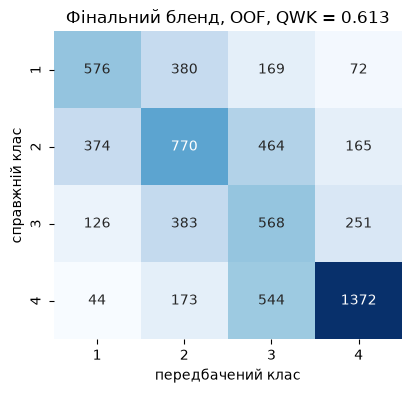

In [18]:
test_preds = {name: fn(F_train, y, F_test) for name, fn in final_fns.items()}
blend_test = rank_blend(list(test_preds.values()))
thr = fit_thresholds(blend_oof, y)
test_class = apply_thresholds(blend_test, thr)
print("пороги на рангах:", thr.round(3))
score_blend, pred_blend = cv_qwk(blend_oof)
print("фінальний бленд, recall по класах (OOF):\n", recall_table(pred_blend).to_string())

sub = pd.DataFrame({"PetID": pets.PetID.values[te_idx], "AdoptionSpeed": test_class})
assert len(sub) == len(te_idx) and sub.PetID.is_unique and set(sub.AdoptionSpeed) <= {1, 2, 3, 4}
sub.to_csv(RES_DIR / "submission.csv", index=False)

dist = pd.DataFrame({"train": pd.Series(y).value_counts(normalize=True).sort_index(),
                     "submission": sub.AdoptionSpeed.value_counts(normalize=True).sort_index()}).round(3)
print(dist.to_string())
print(sub.head())
print("PetID з 8 символів у сабмішені:", sub.PetID[sub.PetID.str.len() == 8].tolist())

pd.DataFrame({"PetID": pets.PetID.values[tr_idx], "AdoptionSpeed": y, "blend_oof": blend_oof, "pred": pred_blend}).to_csv(RES_DIR / "oof_predictions.csv", index=False)
pd.DataFrame({"PetID": sub.PetID, "blend": blend_test, **test_preds}).to_csv(RES_DIR / "test_predictions.csv", index=False)

plt.figure(figsize=(4.5, 4))
sns.heatmap(confusion_matrix(y, pred_blend, labels=CLASSES), annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
plt.xlabel("передбачений клас"); plt.ylabel("справжній клас"); plt.title(f"Фінальний бленд, OOF, QWK = {score_blend:.3f}")
plt.savefig(FIG_DIR / "models_confusion.png", dpi=120, bbox_inches="tight")
plt.show()

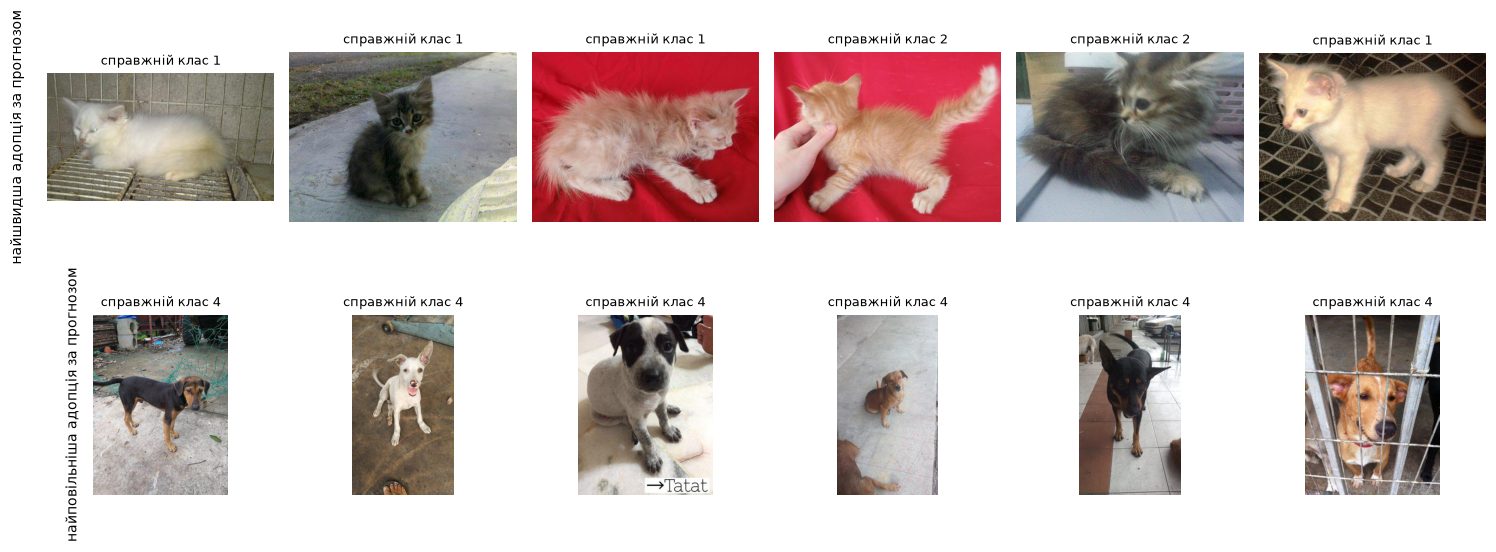

In [19]:
first_photo = photos.drop_duplicates("PetID").set_index("PetID").path
order = np.argsort(blend_oof)
picks = {"найшвидша адопція за прогнозом": order[:6], "найповільніша адопція за прогнозом": order[-6:]}
fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for row, (title, idx) in zip(axes, picks.items()):
    for ax, i in zip(row, idx):
        ax.imshow(Image.open(first_photo[pets.PetID.values[tr_idx[i]]]))
        ax.axis("off")
        ax.set_title(f"справжній клас {y[i]}", fontsize=9)
    row[0].text(-0.1, 0.5, title, transform=row[0].transAxes, rotation=90, va="center", ha="right", fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "models_extremes.png", dpi=120, bbox_inches="tight")
plt.show()

## Підсумок

Фінальний бленд (multiclass і порядковий LightGBM з параметрами Optuna та CatBoost multiclass): QWK 0.613 на
5 фолдах, розкид по фолдах 0.015. Найкраща одиночна модель, LightGBM multiclass з Optuna, дає 0.616, різниця в
межах розкиду, бленд беру як стійкіший до вибору однієї моделі. Сабмішен лежить у Results/submission.csv.

Що дало результат. Ембеддинги фото: Ridge на CLIP 0.587, на SigLIP2 0.592, разом 0.591, тобто другий енкодер сам
по собі не додає, зате всі фото тварини замість одного першого дають +0.025 (0.587 проти 0.562). Текст окремо
слабкий (0.30-0.34) і додає до фото +0.005. SVR на всіх ембеддингах, найкраща модель першого рівня, 0.609. Стекінг
з ознаками сусідів піднімає до 0.613-0.616: за аблацією прогнози першого рівня коштують 0.022 QWK, кожне сімейство
ознак сусідів 0.002-0.007, PCA ембеддингів майже нічого. Optuna додав +0.005 до регресійного LightGBM, це на рівні
розкиду між фолдами, тож тюнінг тут радше демонстрація процедури.

Дисбаланс: ваги класів QWK не покращують (0.607 проти 0.613 без ваг), пороги вже вирівнюють recall малих класів
(клас 1 з 0.14 при округленні до 0.44 з порогами). За SHAP 57 % внеску йде від моделей першого рівня, 17 % від
PCA фото, 19 % від ознак сусідів. Zero-shot зондування CLIP: чим більше фото схоже на кошеня чи цуценя, тим швидша
адопція (кореляція -0.32), кілька тварин на одному фото адоптуються повільніше (+0.11).

Що ще можна спробувати: SigLIP2 у більшій роздільній здатності (384), окремі моделі для котів і собак, кілька сідів
розбиття з усередненням, ознаки сусідів на рівні окремих фото. Донавчання енкодерів end-to-end перевірено в
ноутбуці 04: на одному фолді донавчений ResNet-50 дає 0.44 проти 0.58 у заморожених CLIP + SigLIP2 з Ridge.